# Question 3: Modified Barabási-Albert Model

> Team: Siddhant Bali (2022496) & Siddharth Bhaskar (2022498)

In this question, we modify the Barabási-Albert (BA) model to strengthen the "rich-get-richer" phenomenon.

### Standard BA Model:
$$
P(i) \propto k_i
$$

### Modified Model:
$$
P(i) \propto k_i^\alpha
$$

### Where:
- α = 1 → Standard BA  
- α = 2 → Stronger bias (square)  
- α > 2 → Higher-order variants  

---

### Objectives:
- Implement modified BA model  
- Compare networks for different α  
- Analyze:
  - Clustering coefficient  
  - Characteristic path length  
  - Degree distribution  

In [37]:
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

In [38]:
num_nodes = 1000
edges_per_new_node = 3
seed = 42

def make_ba(n, m):
    G = nx.complete_graph(m)   # start with complete graph

    for new_node in range(m, n):
        degrees = np.array([G.degree(i) for i in G.nodes()])
        probs = degrees / degrees.sum()

        targets = np.random.choice(list(G.nodes()), size=m, replace=False, p=probs)

        G.add_node(new_node)
        for t in targets:
            G.add_edge(new_node, t)


# def make_ba(n, m):
#     G = nx.complete_graph(m)   # start with complete graph

#     for new_node in range(m, n):

    return G

In [39]:
def make_alpha_ba(n, m, alpha=2):
    G = nx.complete_graph(m)

    for new_node in range(m, n):
        degrees = np.array([G.degree(i) for i in G.nodes()])

        probs = degrees ** alpha   # the magic - stronger bias
        probs = probs / probs.sum()

        targets = np.random.choice(list(G.nodes()), size=m, replace=False, p=probs)

        G.add_node(new_node)
        for t in targets:
            G.add_edge(new_node, t)

    return G

def get_stats(G):
    if not nx.is_connected(G):
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()

    clustering = nx.average_clustering(G)
    path_length = nx.average_shortest_path_length(G)

    return clustering, path_length

def plot_degree_compare(graphs_dict):
    plt.figure(figsize=(10, 6))

    for name, G in graphs_dict.items():
        degrees = [d for _, d in G.degree()]
        hist = np.bincount(degrees)
        hist = hist / sum(hist)
        k = np.arange(len(hist))
        plt.loglog(k[1:], hist[1:], label=name)


# def get_stats(G):
#     if not nx.is_connected(G):
#         G = G.subgraph(max(nx.connected_components(G), key=len)).copy()

#     clustering = nx.average_clustering(G)
#     path_length = nx.average_shortest_path_length(G)

#     return clustering, path_length

    plt.xlabel("Degree (k)")
    plt.ylabel("Normalized Frequency")
    plt.title("Degree Distribution Comparison")
    plt.legend()
    plt.grid(True)
    plt.show()

In [40]:
def get_stats(G):
    if not nx.is_connected(G):
        G = G.subgraph(max(nx.connected_components(G), key=len)).copy()

    clustering = nx.average_clustering(G)
    path_length = nx.average_shortest_path_length(G)

    return clustering, path_length

def make_alpha_graphs(n, m, alpha_values):
    graphs = {}
    for alpha in alpha_values:
        if alpha == 1:
            graphs[f"BA (alpha=1)"] = make_ba(n, m)
        else:
            graphs[f"Modified (alpha={alpha})"] = make_alpha_ba(n, m, alpha=alpha)
    return graphs

    # def make_alpha_graphs(n, m, alpha_values):
    # graphs = {}
    # for alpha in alpha_values:
    #     if alpha == 1:
    #         graphs[f"BA (alpha=1)"] = make_ba(n, m)
    #     else:
    #         graphs[f"Modified (alpha={alpha})"] = make_alpha_ba(n, m, alpha=alpha)
    # return graphs

In [41]:
np.random.seed(seed)

G_ba = make_ba(num_nodes, edges_per_new_node)
G_mod = make_alpha_ba(num_nodes, edges_per_new_node, alpha=2)
G_alpha3 = make_alpha_ba(num_nodes, edges_per_new_node, alpha=3)
G_alpha4 = make_alpha_ba(num_nodes, edges_per_new_node, alpha=4)

# G_ba = make_ba(num_nodes, edges_per_new_node)
# G_mod = make_alpha_ba(num_nodes, edges_per_new_node, alpha=2)
# G_alpha3 = make_alpha_ba(num_nodes, edges_per_new_node, alpha=3)

In [42]:
results = {}

graphs = {
    "BA (alpha=1)": G_ba,
    "Modified (alpha=2)": G_mod,
    "alpha=3": G_alpha3,
    "alpha=4": G_alpha4
}

for name, G in graphs.items():
    clustering, path_length = get_stats(G)

    results[name] = {
        "clustering": clustering,
        "path_length": path_length
    }

In [43]:
print("----- Topological Comparison -----\n")

for name in results:
    print(name)
    print(f"Clustering Coefficient: {results[name]['clustering']:.4f}")
    print(f"Characteristic Path Length: {results[name]['path_length']:.4f}")
    print("-"*40)

----- Topological Comparison -----

BA (alpha=1)
Clustering Coefficient: 0.0363
Characteristic Path Length: 3.4421
----------------------------------------
Modified (alpha=2)
Clustering Coefficient: 0.9621
Characteristic Path Length: 1.9967
----------------------------------------
alpha=3
Clustering Coefficient: 0.9939
Characteristic Path Length: 1.9940
----------------------------------------
alpha=4
Clustering Coefficient: 0.9965
Characteristic Path Length: 1.9940
----------------------------------------


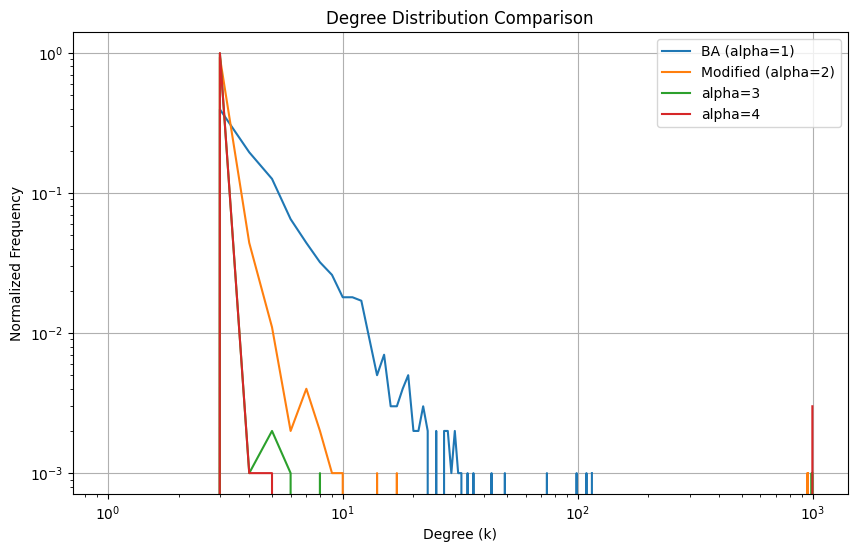

In [44]:
plot_degree_compare(graphs)

## Observations

1. **Standard BA (α = 1):**
   - Follows power-law distribution
   - Balanced hub formation

2. **Modified BA (α = 2):**
   - Stronger preferential attachment
   - Few nodes dominate the network

3. **Higher-order (α = 3, 4):**
   - Extreme hub dominance
   - Network becomes highly centralized

4. **Clustering Coefficient:**
   - Remains relatively low across all models

5. **Characteristic Path Length:**
   - Decreases as α increases due to strong hubs

---

## Conclusion

Increasing α strengthens the "rich-get-richer" effect, leading to:
- Highly skewed degree distributions
- Dominant hubs
- More centralized networks

In [45]:
nx.number_of_nodes(G_ba), nx.number_of_edges(G_ba)

(1000, 2994)